**Author(s)** : Cheikhou Akhmed KANE <br>
**Description** : Baseline Experiment ETC Meta & Contextual on 500 episodes with T = 20

# Baseline Experiment

Lorem ipsum

## Imports & Configuration

In [1]:
import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

from gym_agro_carbon.envs.gama_env import GamaAgroCarbonEnv
from gym_agro_carbon.envs.grid import EnvSpec
from gym_agro_carbon.models.context import ContextSpec, ContextEncoder
from gym_agro_carbon.models.reward import RewardSpec, RewardModel, InvestmentConfig
from gym_agro_carbon.bandits.etc import MetaExploreThenCommitBandit
from gym_agro_carbon.evaluation.oracle import build_oracle_policy
from gym_agro_carbon.evaluation.regret import RegretTracker
from gym_agro_carbon.evaluation.runner import run_agent 
from gym_agro_carbon.utils.experiment import setup_experiment_dirs, save_summary_stats

# --- Configuration des chemins ---
notebook_dir = Path().resolve()
project_root = notebook_dir.parent 
gaml_file = project_root / "gama_model" / "models" / "EcoSysML" / "main.gaml"

# --- Paramètres de l'expérience ---
EXP_NAME = "baseline_meta_etc_vna"
T_HORIZON = 20
N_EPISODES = 500
ALPHA = 0.6
DELTA = 0.1
NUM_ACTIONS = 4

# Initialisation des dossiers
dirs = setup_experiment_dirs(EXP_NAME)

## Model Initialisation

In [2]:
# Spécification du contexte (8 types de sol, maturité à 7 ans)
context_spec = ContextSpec(S=8, M=7)
encoder = ContextEncoder(context_spec)

# Configuration de l'action Arbre (ID 2) en mode investissement
tree_config = InvestmentConfig(
    is_investment=True,
    duration=7,              # H = 7 saisons de croissance
    terminal_value=12.0,     # V_mature
    mu_delta_soc_expected=1.0, # mu_delta_soc_tree dans GAMA
    mu_yield_expected=0.0      # mu_yield_tree dans GAMA
)

# Modèle de récompense aligné sur GAMA (Moyennes SOC: 0.4, 0.6, 1.0, 0.2)
reward_spec = RewardSpec(
    context_spec=context_spec,
    alpha=ALPHA,
    discount_rate=DELTA,
    investment_configs={2: tree_config}
)
reward_model = RewardModel(reward_spec, encoder)

# Construction de la politique Oracle (Maximisation de la VNA sur l'horizon H)
oracle = build_oracle_policy(encoder=encoder, reward_model=reward_model, num_actions=NUM_ACTIONS)

## Experiment

In [4]:
env_spec = EnvSpec(H=10, W=10, T=T_HORIZON, S=8, M=7, alpha=ALPHA)

# L'instanciation est synchrone conformément au handshake
env = GamaAgroCarbonEnv(
    env_spec, 
    context_spec, 
    reward_model, 
    gaml_file_path=str(gaml_file)
)

# Initialisation de l'Agent Meta-ETC et du Tracker
agent = MetaExploreThenCommitBandit(context_encoder=encoder, num_actions=NUM_ACTIONS)
regret_tracker = RegretTracker(encoder, reward_model, oracle)

In [5]:
N_RUNS = 10
all_runs_regrets = []  # Matrice pour stocker (N_RUNS, N_EPISODES)

print(f"🚀 Lancement de l'étude de stabilité : {EXP_NAME} ({N_RUNS} runs)")

try:
    for run_idx in range(N_RUNS):
        # 1. Définition d'un nouveau seed pour ce run
        run_seed = 42 + run_idx 
        np.random.seed(run_seed) # Seed pour le bandit (Python/Numpy)
        
        # 2. Réinitialisation complète de l'Agent et du Tracker pour chaque run
        agent = MetaExploreThenCommitBandit(context_encoder=encoder, num_actions=NUM_ACTIONS)
        regret_tracker = RegretTracker(encoder, reward_model, oracle)
        
        run_regrets = []
        
        # Boucle d'épisodes pour le run actuel
        for ep in tqdm(range(N_EPISODES), desc=f"Run {run_idx+1}/{N_RUNS}"):
            
            # GAMA reçoit le seed uniquement au premier reset du run pour initialiser la simu
            # Les épisodes suivants du même run continuent la séquence aléatoire
            current_seed = run_seed if ep == 0 else None
            
            trajectory, final_regret = run_agent(
                env=env,
                agent=agent,
                reward_model=reward_model,
                regret_tracker=regret_tracker,
                T=T_HORIZON,
                episode_idx=ep,
                seed=current_seed  # <--- Injection du seed pour GAMA
            )
            
            run_regrets.append(final_regret)
            
            # Sauvegarde des logs uniquement pour le premier run
            if run_idx == 0 and ep % 50 == 0:
                pd.DataFrame(trajectory).to_csv(dirs["logs"] / f"trajectory_ep_{ep}.csv", index=False)

        all_runs_regrets.append(run_regrets)

    # 3. Sauvegarde finale
    all_runs_regrets = np.array(all_runs_regrets)
    np.save(dirs["summary"] / "all_runs_regrets.npy", all_runs_regrets)
    print("✅ Étude de stabilité terminée.")

finally:
    env.close()
    print("🏁 Connexion GAMA fermée.")

🚀 Lancement de l'étude de stabilité : baseline_meta_etc_vna (10 runs)


Run 10/10: 100%|████████████████████████| 500/500 [01:39<00:00,  5.02it/s]

✅ Étude de stabilité terminée.
🏁 Connexion GAMA fermée.


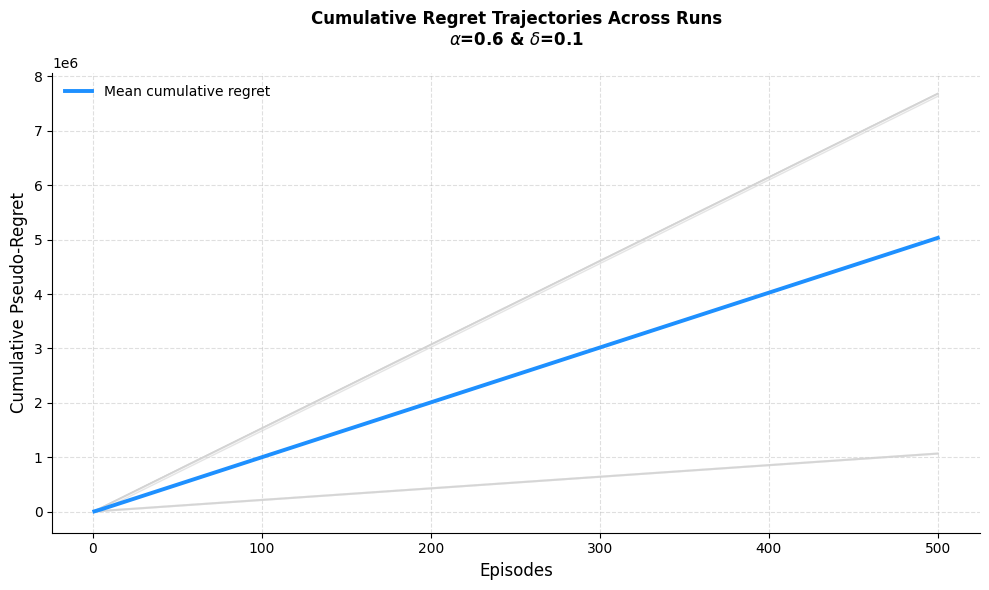

📊 Graph saved successfully at: figures\baseline_meta_etc_vna\runs_regret_trajectories.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Préparation du répertoire de sauvegarde
fig_dir = Path(f"./figures/{EXP_NAME}")
fig_dir.mkdir(parents=True, exist_ok=True)
save_path = fig_dir / "runs_regret_trajectories.png"

# 2. Données
episodes = np.arange(1, N_EPISODES + 1)

# Regret cumulé par épisode pour chaque run
runs_cum_regret = np.cumsum(all_runs_regrets, axis=1)

# Moyenne des runs
mean_cum_regret = runs_cum_regret.mean(axis=0)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Trajectoires individuelles (gris clair)
for r in range(N_RUNS):
    ax.plot(
        episodes,
        runs_cum_regret[r],
        color="lightgray",
        lw=1,
        alpha=0.6
    )

# Moyenne (ligne principale)
ax.plot(
    episodes,
    mean_cum_regret,
    color="dodgerblue",
    lw=2.8,
    label="Mean cumulative regret"
)

# 4. Titres et labels
ax.set_title(
    f"Cumulative Regret Trajectories Across Runs\n"
    f"$\\alpha$={ALPHA} & $\\delta$={DELTA}",
    fontsize=12,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Episodes", fontsize=12)
ax.set_ylabel("Cumulative Pseudo-Regret", fontsize=12)

# 5. Style (comme ton graphique précédent)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle="--", alpha=0.4)

ax.legend(frameon=False)

plt.tight_layout()

# 6. Sauvegarde
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📊 Graph saved successfully at: {save_path}")

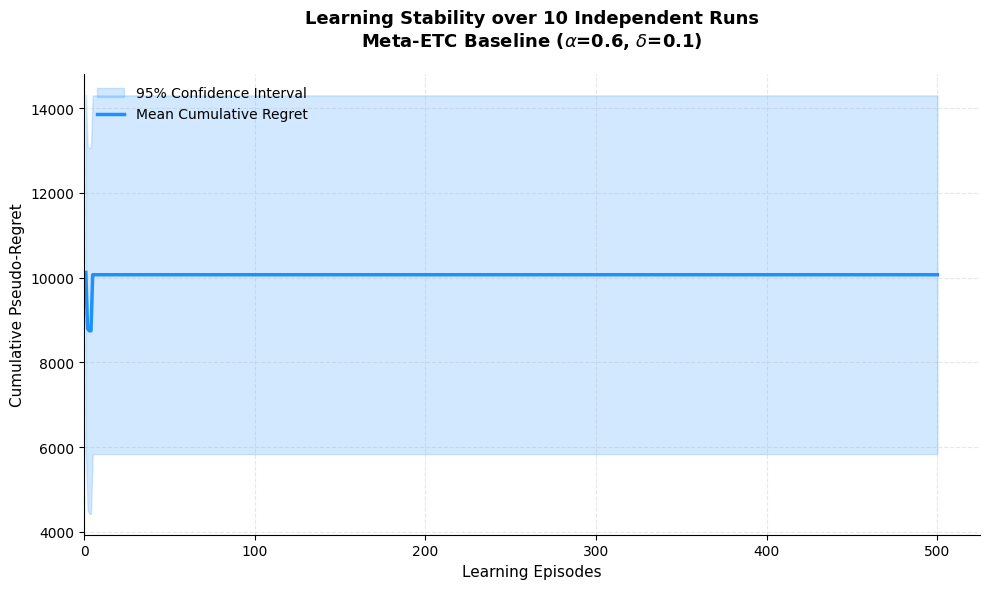

📊 Graphique de stabilité sauvegardé : figures\baseline_meta_etc_vna\meta_etc_learning_stability.png


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Chargement des données
# On suppose que le fichier a été sauvegardé dans le dossier 'summary'
data_path = dirs["summary"] / "all_runs_regrets.npy"
if not data_path.exists():
    print(f"⚠️ Fichier non trouvé : {data_path}. Assurez-vous d'avoir terminé les 10 runs.")
else:
    all_runs_regrets = np.load(data_path) # Shape: (K_runs, N_episodes)
    
    K = all_runs_regrets.shape[0]
    N_episodes = all_runs_regrets.shape[1]
    episodes = np.arange(1, N_episodes + 1)

    # 2. Calculs statistiques par épisode
    # Rt_bar : Moyenne des regrets cumulés sur les K runs
    mean_regret = np.mean(all_runs_regrets, axis=0)
    # st : Écart-type entre les runs
    std_regret = np.std(all_runs_regrets, axis=0, ddof=1) 
    # CI : Intervalle de confiance à 95% (1.96 * SEM)
    ci = 1.96 * (std_regret / np.sqrt(K))

    # 3. Création du graphique
    fig, ax = plt.subplots(figsize=(10, 6))

    # Tracé de la zone d'ombre (Intervalle de confiance)
    ax.fill_between(episodes, 
                    mean_regret - ci, 
                    mean_regret + ci, 
                    color='dodgerblue', 
                    alpha=0.2, 
                    label='95% Confidence Interval')

    # Tracé de la ligne moyenne
    ax.plot(episodes, mean_regret, color='dodgerblue', lw=2.5, label='Mean Cumulative Regret')

    # 4. Style et Cosmétique (Standards Scientifiques)
    ax.set_title(f"Learning Stability over {K} Independent Runs\n"
                 f"Meta-ETC Baseline ($\\alpha$={ALPHA}, $\\delta$={DELTA})", 
                 fontsize=13, fontweight='bold', pad=20)
    ax.set_xlabel("Learning Episodes", fontsize=11)
    ax.set_ylabel("Cumulative Pseudo-Regret", fontsize=11)

    # Forcer l'origine à (0,0) et enlever les bordures inutiles
    #ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Grille légère et légende
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper left', frameon=False, fontsize=10)

    # 5. Sauvegarde Haute Résolution
    save_path = Path(f"./figures/{EXP_NAME}/meta_etc_learning_stability.png")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 Graphique de stabilité sauvegardé : {save_path}")

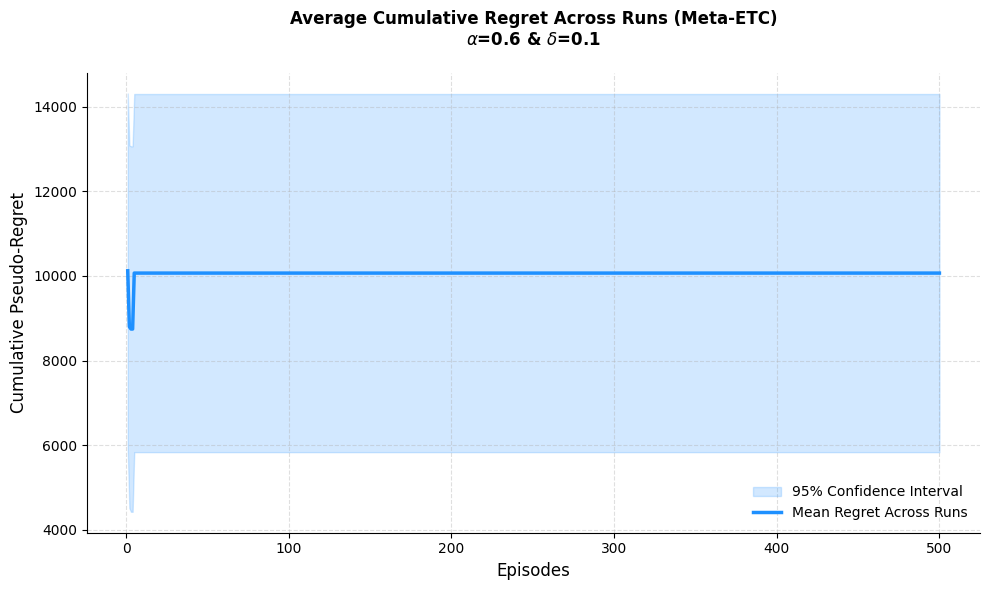

📊 Graph saved successfully at: figures\baseline_meta_etc_vna\meta_etc_mean_regret_ci.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Préparation du répertoire de sauvegarde
fig_dir = Path(f"./figures/{EXP_NAME}")
fig_dir.mkdir(parents=True, exist_ok=True)
save_path = fig_dir / "meta_etc_mean_regret_ci.png"

# 2. Données
episodes = np.arange(1, N_EPISODES + 1)

# Moyenne du regret par épisode à travers les runs
mean_regret = np.mean(all_runs_regrets, axis=0)

# Écart-type par épisode à travers les runs
std_regret = np.std(all_runs_regrets, axis=0, ddof=1)

# Erreur standard
se_regret = std_regret / np.sqrt(N_RUNS)

# Intervalle de confiance à 95%
ci95 = 1.96 * se_regret
lower = mean_regret - ci95
upper = mean_regret + ci95

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Bande de confiance
ax.fill_between(
    episodes,
    lower,
    upper,
    color="dodgerblue",
    alpha=0.2,
    label="95% Confidence Interval"
)

# Courbe moyenne
ax.plot(
    episodes,
    mean_regret,
    color="dodgerblue",
    lw=2.5,
    label="Mean Regret Across Runs"
)

# 4. Titres et labels
ax.set_title(
    f"Average Cumulative Regret Across Runs (Meta-ETC)\n"
    f"$\\alpha$={ALPHA} & $\\delta$={DELTA}",
    fontsize=12,
    fontweight="bold",
    pad=20
)
ax.set_xlabel("Episodes", fontsize=12)
ax.set_ylabel("Cumulative Pseudo-Regret", fontsize=12)

# 5. Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()

# 6. Sauvegarde
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📊 Graph saved successfully at: {save_path}")

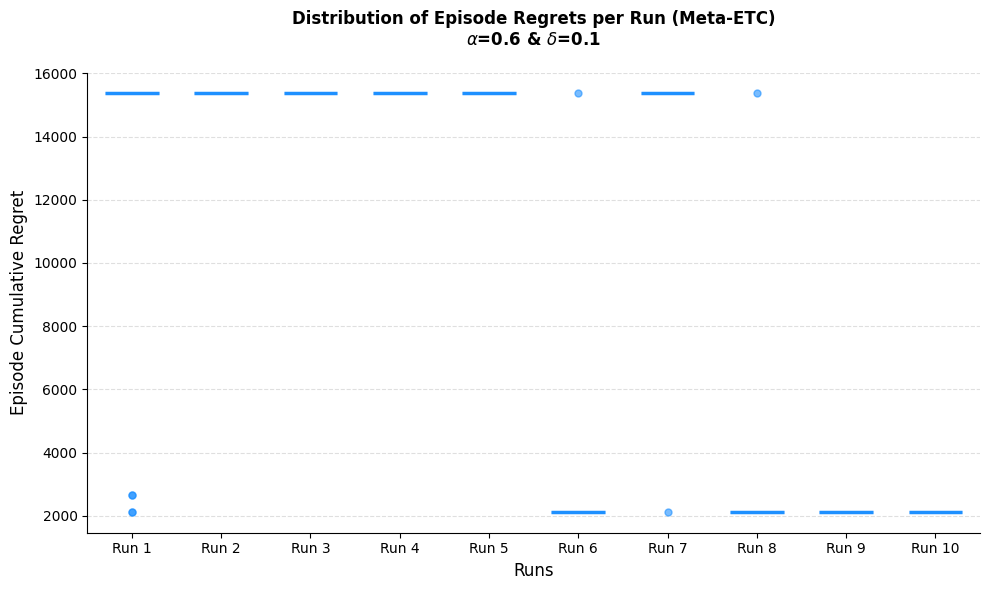

📊 Graph saved successfully at: figures\baseline_meta_etc_vna\meta_etc_boxplot_runs.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Préparation du répertoire de sauvegarde
fig_dir = Path(f"./figures/{EXP_NAME}")
fig_dir.mkdir(parents=True, exist_ok=True)
save_path = fig_dir / "meta_etc_boxplot_runs.png"

# 2. Données
# Chaque colonne correspond à un run
data = [all_runs_regrets[i] for i in range(N_RUNS)]

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10,6))

ax.boxplot(
    data,
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor="dodgerblue", alpha=0.25, color="dodgerblue", linewidth=2),
    medianprops=dict(color="dodgerblue", linewidth=2.5),
    whiskerprops=dict(color="dodgerblue", linewidth=1.8),
    capprops=dict(color="dodgerblue", linewidth=1.8),
    flierprops=dict(marker='o', markerfacecolor="dodgerblue", markeredgecolor="dodgerblue", alpha=0.6, markersize=5)
)

# 4. Titres et labels
ax.set_title(
    f"Distribution of Episode Regrets per Run (Meta-ETC)\n"
    f"$\\alpha$={ALPHA} & $\\delta$={DELTA}",
    fontsize=12,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Runs", fontsize=12)
ax.set_ylabel("Episode Cumulative Regret", fontsize=12)

ax.set_xticks(np.arange(1, N_RUNS+1))
ax.set_xticklabels([f"Run {i+1}" for i in range(N_RUNS)])

# 5. Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# 6. Sauvegarde
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"📊 Graph saved successfully at: {save_path}")

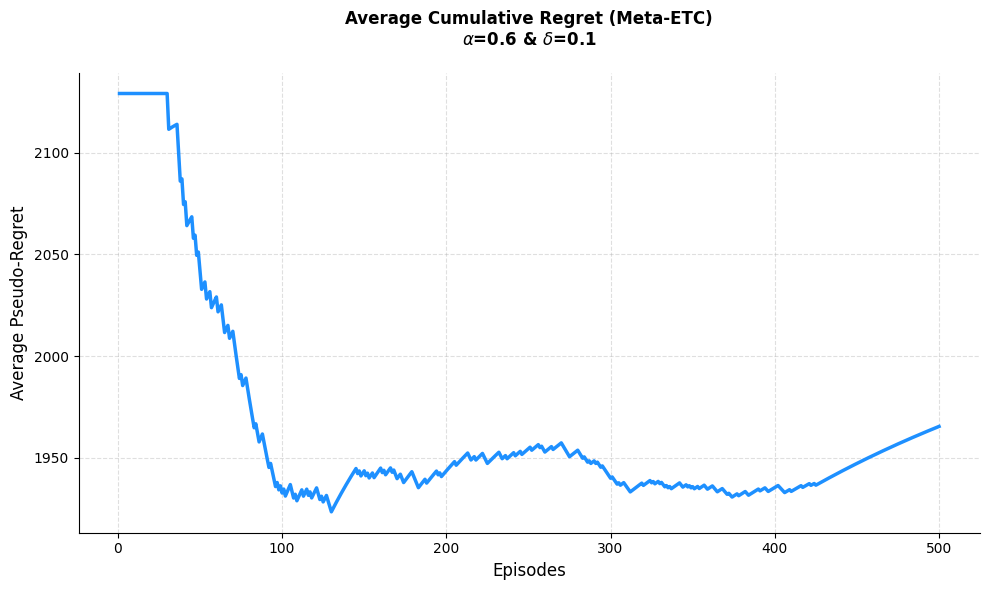

📊 Graph saved successfully at: figures\baseline_meta_etc_vna\meta_etc_regretcum.png


In [14]:
import os
import matplotlib.pyplot as plt

# 1. Préparation du répertoire de sauvegarde
fig_dir = Path(f"./figures/{EXP_NAME}")
fig_dir.mkdir(parents=True, exist_ok=True)
save_path = fig_dir / "meta_etc_regretcum.png"

# 2. Calcul des données
episodes = np.arange(1, N_EPISODES + 1)
avg_cumulative_regret = np.cumsum(all_cumulative_regrets) / episodes

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(episodes, avg_cumulative_regret, color='dodgerblue', lw=2.5, label='Meta-ETC Baseline')

# Configuration des titres et labels (Anglais)
ax.set_title(f"Average Cumulative Regret (Meta-ETC)\n"
             f"$\\alpha$={ALPHA} & $\\delta$={DELTA}", 
             fontsize=12, fontweight='bold', pad=20)
ax.set_xlabel("Episodes", fontsize=12)
ax.set_ylabel("Average Pseudo-Regret", fontsize=12)

# Esthétique : suppression des spines (top/right) et grille légère
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

# Optimisation des marges
plt.tight_layout()

# 4. Sauvegarde haute résolution (DPI 300)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Graph saved successfully at: {save_path}")

In [12]:
def plot_learned_policy(agent, encoder):
    """Affiche une table des actions recommandées par type de sol et âge."""
    S = encoder.spec.S
    M = encoder.spec.M
    policy_matrix = np.zeros((S, M + 1))

    for s in range(1, S + 1):
        for tau in range(M + 1):
            ctx_id = encoder.to_id(s, tau)
            # L'agent ETC choisit l'action avec la meilleure moyenne estimée
            policy_matrix[s-1, tau] = np.argmax(agent.estimates[ctx_id])

    plt.figure(figsize=(12, 8))
    sns.heatmap(policy_matrix, annot=True, cmap="YlGn", cbar_klabel="Action ID")
    plt.title("Learned Policy: Optimal Action per Context (Soil, Age)")
    plt.xlabel("Tree Age (tau)")
    plt.ylabel("Soil Type (s)")
    plt.show()